# Making figures for ULMS G4X sections based on the scviva_2 annotations

In [ ]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_plot
import seaborn as sns

sc.settings.n_jobs = -1  # Use all available cores
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = False # turn the grid off
mpl.rcParams['pdf.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
mpl.rcParams['ps.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
plt.ioff()
sc.settings.autoshow = False
plt.rcParams['savefig.dpi'] = 300
sc.set_figure_params(dpi_save=300, facecolor='white')
plt.rcParams['axes.grid'] = False # turn the grid off

module_path = '/labs/delitto/james/functions/'
sys.path.append(module_path)
import jpasq

# version control
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scanpy:", sc.__version__)
print("spatialdata:", sd.__version__)
print("spatialdata_plot:", spatialdata_plot.__version__)
print("squidpy:", sq.__version__)
print("sns:", sns.__version__)

In [ ]:
# set up directories
CURRENT_DIR = Path.cwd()
PARENT_DIR = CURRENT_DIR.parent
print(PARENT_DIR)

OUTPUT_MASTER_DIR = jpasq.create_output_dir(PARENT_DIR, 'scviva_figures', change_dir=True)

DATA_DIR = PARENT_DIR.parent.parent/ 'G4X/G4X_raw'
print(DATA_DIR)

ANNDATA_DIR = PARENT_DIR / 'annotation'
print(f"ANNDATA_DIR is {ANNDATA_DIR}")

In [ ]:
# order sections properly. This is how they will print on the page.
sections = [
    'B01', 'C01', 'D01', 'E01', 
    'F01', 'G01', 'H01', 'A02', 
    'B02', 'C02', 'E02', 'F02', 
    'G02', 'H02', 'A03', 'B03', 
    'C03', 'D03', 'E03', 'F03', 
    'G03', 'H03', 'A04', 'B04', 
    'C04', 'D04',
]

# Working with the basic cell types

In [ ]:
# load data
all_cells = sc.read_h5ad(ANNDATA_DIR / 'scviva_celltype.h5ad')
all_cells

In [ ]:
all_cells.uns['celltype_colors'][9] = '#ffbb78'

celltypes = all_cells.obs['celltype'].cat.categories.tolist()
print(*celltypes)
print(len(celltypes))
celltype_colors = all_cells.uns['celltype_colors'].tolist()
print(*celltype_colors)
print(len(celltype_colors))

In [ ]:
sc.pl.umap(all_cells, color='celltype')

In [ ]:
# Color palette for celltypes
# Make sure the celltype colors line up
ct_categories = all_cells.obs['celltype'].cat.categories
ct_colors = all_cells.uns['celltype_colors']
ct_palette = dict(zip(ct_categories, ct_colors))

In [ ]:
np.unique(all_cells.obs['Section'])

## Plot cell types in all annotated sections

In [ ]:
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, 'all_sections', change_dir=True)

In [ ]:
# # test example
# section = sections[0]
# section_adata = all_cells[all_cells.obs['Section'] == section]
# section_adata.obsm['spatial'] = section_adata.obsm.pop('X_spatial') # transition back to squidpy expectations

# section_adata.obs['celltype'] = section_adata.obs['celltype'].cat.set_categories(ct_categories, ordered=True)
# section_adata.uns['celltype_colors'] = ct_colors

# sq.pl.spatial_scatter(section_adata, library_id='spatial', shape=None, size=0.5, color='celltype', legend_fontsize='xx-small', save='test.png')

In [ ]:
# set the cell type categories and colors for each individual section, save those anndatas in a list, and plot each individual annotated section
adata_list = []
for section in sections:
    section_adata = all_cells[all_cells.obs['Section'] == section]
    section_adata.obsm['spatial'] = section_adata.obsm.pop('X_spatial') # transition back to squidpy expectations
    section_adata.obs['celltype'] = section_adata.obs['celltype'].cat.set_categories(ct_categories, ordered=True)
    section_adata.uns['celltype_colors'] = ct_colors
    sq.pl.spatial_scatter(section_adata, 
                          library_id='spatial', 
                          shape=None, 
                          size=0.5,
                          color='celltype', 
                          save=f'{section}_annotated.png', 
                          legend_fontsize='xx-small')
    sq.pl.spatial_scatter(section_adata, 
                          library_id='spatial', 
                          shape=None, 
                          size=0.5,
                          color='celltype', 
                          save=f'{section}_annotated.pdf', 
                          legend_fontsize='xx-small')
    plt.close()
    adata_list.append(section_adata) # save these for the next cell

In [ ]:
# plot all annotated sections on one page - all cell types
fig, axes = plt.subplots(ncols=4, nrows=7, figsize=(16, 20))
axes = axes.flatten()

for i, adata in enumerate(adata_list):
    [section] = np.unique(adata.obs['Section']).tolist()
    sq.pl.spatial_scatter(adata, 
                          shape=None, 
                          size=0.5, 
                          library_id='spatial', 
                          color='celltype', 
                          ax=axes[i], 
                          legend_loc=None, 
                          frameon=False)
    axes[i].set_title(f"{section}")

    # Remove the legend if it exists
    legend = axes[i].get_legend()
    if legend:
        legend.remove()

    # Turn off x and y axis labels
    axes[i].tick_params(axis='x', labelbottom=False)
    axes[i].tick_params(axis='y', labelleft=False)

# Hide any unused axes if there are fewer AnnData objects than subplots
for j in range(len(adata_list), len(axes)):
    axes[j].axis('off')  # Hide unused axes

plt.tight_layout()
plt.savefig('all_sections_annotated.pdf')
plt.savefig('all_sections_annotated.png', dpi=300)
plt.close()

# Plotting cell types on selected sections

## F01 - sheet-like

In [ ]:
# subset the annotated anndata
section = 'F01'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

In [ ]:
# Make the colors consistent with the original object.
groups = np.unique(adata.obs['celltype']).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color='celltype', groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
bb_xmin = 5000
bb_ymin = 5000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color='celltype', groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
cropped_sdata

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color='celltype', groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color='celltype', groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

## D01: nest-like

In [ ]:
# subset the annotated anndata
section = 'D01'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

In [ ]:
# Make the colors consistent with the original object.
groups = np.unique(adata.obs['celltype']).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color='celltype', groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
bb_xmin = 4000
bb_ymin = 12000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color='celltype', groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
cropped_sdata

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color='celltype', groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color='celltype', groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

## H03 - myxoid

In [ ]:
# subset the annotated anndata
section = 'H03'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

In [ ]:
# Make the colors consistent with the original object.
groups = np.unique(adata.obs['celltype']).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color='celltype', groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
bb_xmin = 3000
bb_ymin = 7500
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color='celltype', groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
cropped_sdata

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color='celltype', groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color='celltype', groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

## F02 - necrosis

In [ ]:
# 1) subset the annotated anndata
section = 'F02'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

In [ ]:
# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs['celltype']).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color='celltype', groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
# 3) Cropping coordinates
bb_xmin = 4250
bb_ymin = 3000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
# 4) Plots with red rectangle showing inset

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color='celltype', groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# 5) Crop the sdata
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
cropped_sdata

In [ ]:
# 6) Segmentation, H&E, and segmentation-H&E overlay for the zoomed-in plot

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color='celltype', groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color='celltype', groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

## E02: highlighting the ESR PGR AR cells vs all other cells

In [ ]:
# load data
object_dir = PARENT_DIR / 'objects'
all_cells = sc.read_h5ad(object_dir / 'g4x_all_raw.h5ad')
all_cells

In [ ]:
all_cells.obs['ct'].cat.categories.to_list()

In [ ]:
all_cells.uns['ct_colors']

In [ ]:
ct_map = {
    'CHI3L1-high SMC-like Tumor' : 'Other Tumor',
    'CHI3L1-low SMC-like Tumor' : 'Other Tumor',
    'Ischemic Tumor' : 'Other Tumor',
    'IFN Signaling Tumor' : 'Other Tumor',
    'Cycling IFN Signaling Tumor' : 'Other Tumor',
    'Cycling SMC-low Tumor' : 'Other Tumor',
    'Cycling COL1A1 POSTN Tumor' : 'Other Tumor',
    'COL1A1 POSTN Tumor' : 'Other Tumor',
    'SDC1 PDGFRB Tumor' : 'Other Tumor'
}
all_cells.obs['esr_ct'] = all_cells.obs['ct'].astype('str').replace(ct_map)

ct_dict = {
    'Adipocyte': '#1f77b4',
    'B': '#ff7f0e',
    'Endothelial': '#279e68',
    'Fibroblast': '#d62728',
    'Macrophage': '#aa40fc',
    'Mast': '#8c564b',
    'Necrosis': '#e377c2',
    'Pericyte': '#b5bd61',
    'T_and_NK': '#17becf',
    'ESR1 PGR AR Tumor' : '#008080',
    'Other Tumor': '#ffbb78'
}
assert set(np.unique(all_cells.obs['esr_ct'])) == set(ct_dict)
all_cells.obs['esr_ct'] = pd.Categorical(all_cells.obs['esr_ct'], ordered=True, categories=list(ct_dict))
print(all_cells.obs['esr_ct'])
all_cells.uns['esr_ct_colors'] = list(ct_dict.values())
print(all_cells.uns['esr_ct_colors'])

# Color palette for the celltypes highlighting esr pgr ar cells in this case
# Make sure the celltype colors line up
ct_categories = all_cells.obs['esr_ct'].cat.categories
ct_colors = all_cells.uns['esr_ct_colors']
ct_palette = dict(zip(ct_categories, ct_colors))

In [ ]:
# 1) subset the annotated anndata
section = 'E02'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

In [ ]:
# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs['esr_ct']).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color='esr_ct', groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
# 3) Cropping coordinates
bb_xmin = 5000
bb_ymin = 9000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
# 4) Plots with red rectangle showing inset

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color='esr_ct', groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# 5) Crop the sdata
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
cropped_sdata

In [ ]:
# 6) Segmentation, H&E, and segmentation-H&E overlay for the zoomed-in plot

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color='esr_ct', groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images(elements="hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color='esr_ct', groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# To plot the transcripts, you must convert the gene column to a categorical column
cropped_sdata['transcripts'].compute()
cropped_sdata.points['transcripts']['gene'] = cropped_sdata.points['transcripts']['gene'].astype('category')
cropped_sdata.points['transcripts']

In [ ]:
# Zoom in - H&E and segmentation overlay with transcripts
gene_name=['ESR1']
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color='esr_ct', groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
cropped_sdata.pl.render_points('transcripts', color="gene", groups=gene_name, palette=["yellow"], size=1.0).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_hneoverlay_{gene_name}_points.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_hneoverlay_{gene_name}_points.pdf', dpi=300, bbox_inches='tight')
plt.close()

# Print out all H&Es

In [ ]:
# order sections properly. This is how they will print on the page.
sections = [
    'B01', 'C01', 'D01', 'E01', 
    'F01', 'G01', 'H01', 'A02', 
    'B02', 'C02', 'E02', 'F02', 
    'G02', 'H02', 'A03', 'B03', 
    'C03', 'D03', 'E03', 'F03', 
    'G03', 'H03', 'A04', 'B04', 
    'C04', 'D04',
]

In [ ]:
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, 'hne', change_dir=True)

In [ ]:
# set up the grid
fig, axes = plt.subplots(ncols=4, nrows=7, figsize=(16, 20))
axes = axes.flatten()

# get the H&E image from each section
for i, section in enumerate(sections):
    # load spatialdata object
    sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
    print(sdata)

    img = sdata.images['hne']
    img_np = img.squeeze().values.transpose(1, 2, 0)  # (C, Y, X) -> (Y, X, C)
    axes[i].imshow(img_np.astype('uint8'))
    axes[i].set_title(section, fontsize=20)
    axes[i].axis('off')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("all_hne_images.png", dpi=300, bbox_inches='tight')
plt.savefig("all_hne_images.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Plotting leiden 0.8 resolution of tumor
- Doing this as a quick check of annotations

In [ ]:
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, 'tumor_leiden0_8', change_dir=True)

In [ ]:
object_dir = PARENT_DIR / 'objects'
adata = sc.read_h5ad(object_dir / 'g4x_all_with_leiden0_8.h5ad')
adata

In [ ]:
leiden_cats = adata.obs['ct'].cat.categories.to_list()
leiden_cats

In [ ]:
palette = sns.color_palette("hls", adata.obs['ct'].cat.categories.size)
print(palette)

In [ ]:
# set the cell type categories and colors for each individual section, save those anndatas in a list, and plot each individual annotated section
adata_list = []
for section in sections:
    section_adata = adata[adata.obs['Section'] == section]
    section_adata.obsm['spatial'] = section_adata.obsm.pop('X_spatial') # transition back to squidpy expectations
    section_adata.obs['ct'] = section_adata.obs['ct'].cat.set_categories(leiden_cats, ordered=True)
    section_adata.uns['ct_colors'] = palette
    
    sq.pl.spatial_scatter(section_adata, 
                          library_id='spatial', 
                          shape=None, 
                          color='ct', 
                          size=0.5,
                          legend_fontsize='xx-small')
    plt.tight_layout()
    plt.savefig(f'{section}_leiden1_5.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{section}_leiden1_5.pdf', bbox_inches='tight', dpi=300)
    plt.close()
    adata_list.append(section_adata)

In [ ]:
# plot all annotated sections on one page - all cell types including tumor subtypes
fig, axes = plt.subplots(ncols=4, nrows=7, figsize=(16, 20))
axes = axes.flatten()

for i, adata in enumerate(adata_list):
    [section] = np.unique(adata.obs['Section']).tolist()
    sq.pl.spatial_scatter(adata, 
                          shape=None, 
                          size=0.5, 
                          library_id='spatial', 
                          color='ct', 
                          ax=axes[i], 
                          legend_loc=None, 
                          frameon=False)
    axes[i].set_title(f"{section}")

    # Remove the legend if it exists
    legend = axes[i].get_legend()
    if legend:
        legend.remove()

    # Turn off x and y axis labels
    axes[i].tick_params(axis='x', labelbottom=False)
    axes[i].tick_params(axis='y', labelleft=False)

# Hide any unused axes if there are fewer AnnData objects than subplots
for j in range(len(adata_list), len(axes)):
    axes[j].axis('off')  # Hide unused axes

plt.tight_layout()
plt.savefig('all_sections_leiden1_5_annotated.pdf', dpi=300)
plt.savefig('all_sections_leiden1_5_annotated.png', dpi=300)
plt.close()

# Working with all cell types including tumor subtypes on all sections

## Plot all cell types including tumor subtypes on all sections

In [ ]:
object_dir = PARENT_DIR / 'objects'
adata = sc.read_h5ad(object_dir / 'g4x_all_raw.h5ad')
adata

In [ ]:
ct_categories = adata.obs['ct'].cat.categories.to_list()
print(ct_categories)
ct_colors = adata.uns['ct_colors'] # should be saved in the object already, but let's check
print(ct_colors)

In [ ]:
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, 'all_sections_fine_ct', change_dir=True)

In [ ]:
# set the cell type categories and colors for each individual section, save those anndatas in a list, and plot each individual annotated section
adata_list = []
for section in sections:
    section_adata = adata[adata.obs['Section'] == section]
    section_adata.obsm['spatial'] = section_adata.obsm.pop('X_spatial') # transition back to squidpy expectations
    section_adata.obs['ct'] = section_adata.obs['ct'].cat.set_categories(ct_categories, ordered=True)
    section_adata.uns['ct_colors'] = ct_colors
    sq.pl.spatial_scatter(section_adata, 
                          library_id='spatial', 
                          shape=None, 
                          size=0.5,
                          color='ct', 
                          legend_fontsize='xx-small',
                          frameon=False,
                          axis_label='',
                         )
    plt.tight_layout()
    plt.savefig(f'{section}_annotated.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{section}_annotated.pdf', bbox_inches='tight', dpi=300)
    plt.close()
    adata_list.append(section_adata)

In [ ]:
# plot all annotated sections on one page - all cell types including tumor subtypes
fig, axes = plt.subplots(ncols=4, nrows=7, figsize=(16, 20))
axes = axes.flatten()

for i, adata in enumerate(adata_list):
    [section] = np.unique(adata.obs['Section']).tolist()
    sq.pl.spatial_scatter(adata, 
                          shape=None, 
                          size=0.5, 
                          library_id='spatial', 
                          color='ct', 
                          ax=axes[i], 
                          legend_loc=None, 
                          frameon=False)
    axes[i].set_title(f"{section}")

    # Remove the legend if it exists
    legend = axes[i].get_legend()
    if legend:
        legend.remove()

    # Turn off x and y axis labels
    axes[i].tick_params(axis='x', labelbottom=False)
    axes[i].tick_params(axis='y', labelleft=False)

# Hide any unused axes if there are fewer AnnData objects than subplots
for j in range(len(adata_list), len(axes)):
    axes[j].axis('off')  # Hide unused axes

plt.tight_layout()
plt.savefig('all_sections_annotated.pdf', dpi=300)
plt.savefig('all_sections_annotated.png', dpi=300)
plt.close()

## Plot individual sections

In [ ]:
del adata

In [ ]:
object_dir = PARENT_DIR / 'objects'
all_cells = sc.read_h5ad(object_dir / 'g4x_all_raw.h5ad')
all_cells

In [ ]:
ct_key = 'ct'

# Color palette for celltypes
# Make sure the celltype colors line up
ct_categories = all_cells.obs[ct_key].cat.categories
ct_colors = all_cells.uns[f'{ct_key}_colors']
ct_palette = dict(zip(ct_categories, ct_colors))

### G02 - Cycling COL1A1 POSTN around blood vessels

In [ ]:
# 1) subset the annotated anndata
section = 'G02'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

In [ ]:
# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
# 3) Cropping coordinates
bb_xmin = 10000
bb_ymin = 5000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
# 4) plot full segmentation and H&E with red box outlinining where you will zoom in
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# 5) Crop the sdata to the inset version
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
cropped_sdata

In [ ]:
# 6) plot the inset segmentation, hne, and segmentation/hne overlay
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

### B01

In [ ]:
# 1) subset the annotated anndata
section = 'B01'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

In [ ]:
# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
# 3) Cropping coordinates
bb_xmin = 8000
bb_ymin = 2700
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
# 4) plot full segmentation and H&E with red box outlinining where you will zoom in
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# 5) Crop the sdata to the inset version
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
cropped_sdata

In [ ]:
# 6) plot the inset segmentation, hne, and segmentation/hne overlay
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

### B02

In [ ]:
# 1) subset the annotated anndata
section = 'B02'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

In [ ]:
# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
# 3) Cropping coordinates
bb_xmin = 9000
bb_ymin = 5000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
# 4) plot full segmentation and H&E with red box outlinining where you will zoom in
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# 5) Crop the sdata to the inset version
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
cropped_sdata

In [ ]:
# 6) plot the inset segmentation, hne, and segmentation/hne overlay
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

### H02

In [ ]:
# 1) subset the annotated anndata
section = 'H02'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, section, change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
# 3) Cropping coordinates
bb_xmin = 1500
bb_ymin = 3800
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
# 4) plot full segmentation and H&E with red box outlinining where you will zoom in
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# 5) Crop the sdata to the inset version
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
print(cropped_sdata)

In [ ]:
# 6) plot the inset segmentation, hne, and segmentation/hne overlay
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

### E02 - all tumor subtypes, not just ESR

In [ ]:
# 1) subset the annotated anndata
section = 'E02'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, f'{section}_all', change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [ ]:
# 3) Cropping coordinates
bb_xmin = 5000
bb_ymin = 9000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [ ]:
# 4) plot full segmentation and H&E with red box outlinining where you will zoom in
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# 5) Crop the sdata to the inset version
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
print(cropped_sdata)

In [ ]:
# 6) plot the inset segmentation, hne, and segmentation/hne overlay
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

### C04

Created output directory /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/C04
Working directory and scanpy figure output directory changed to /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/C04
AnnData object with n_obs × n_vars = 99701 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'Sample', 'ct'
    uns: 'ct_colors'
    obsm: 'X_spatial'


/labs/delitto/james/functions/jpasq.py:192: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(get_proseg_path(directory, section))
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


SpatialData object, with associated Zarr store: /oak/stanford/groups/longaker/ULMS/G4X/G4X_raw/g4-033-076-FC4-L004_424ec4f5bf7d29d9e/C04/segmentation/proseg_no_igj/proseg-output.zarr
├── Images
│     └── 'hne': DataArray[cyx] (3, 19200, 15232)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (99701, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (99701, 304)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), transcripts (Points), cell_boundaries (Shapes)
with the following elements not in the Zarr store:
    ▸ hne (Images)


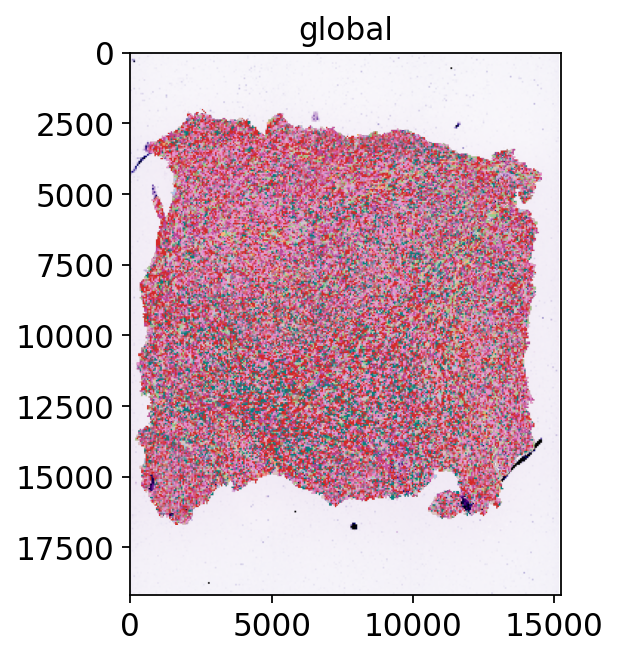

In [11]:
# 1) subset the annotated anndata
section = 'C04'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, f'{section}', change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [12]:
# 3) Cropping coordinates
bb_xmin = 3500
bb_ymin = 12000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [13]:
# 4) plot full segmentation and H&E with red box outlinining where you will zoom in
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

/local/scratch/jpagolia/slrmtmp.51600031/ipykernel_23907/1179017076.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)


In [14]:
# 5) Crop the sdata to the inset version
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
print(cropped_sdata)

# 6) plot the inset segmentation, hne, and segmentation/hne overlay
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     └── 'hne': DataArray[cyx] (3, 2000, 2000)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (1878, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (1878, 304)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), transcripts (Points), cell_boundaries (Shapes)


### B03

Created output directory /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/B03
Working directory and scanpy figure output directory changed to /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/B03
AnnData object with n_obs × n_vars = 59064 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'Sample', 'ct'
    uns: 'ct_colors'
    obsm: 'X_spatial'


/labs/delitto/james/functions/jpasq.py:192: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(get_proseg_path(directory, section))
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


SpatialData object, with associated Zarr store: /oak/stanford/groups/longaker/ULMS/G4X/G4X_raw/g4-033-076-FC4-L003_472c4f0ef9f2af777/B03/segmentation/proseg_no_igj/proseg-output.zarr
├── Images
│     └── 'hne': DataArray[cyx] (3, 19200, 15232)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (59064, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (59064, 304)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), transcripts (Points), cell_boundaries (Shapes)
with the following elements not in the Zarr store:
    ▸ hne (Images)


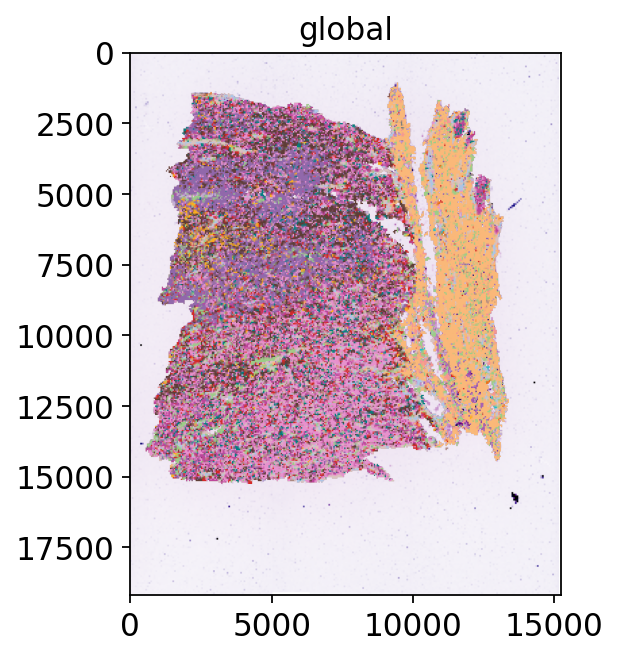

In [16]:
# 1) subset the annotated anndata
section = 'B03'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, f'{section}', change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [17]:
# 3) Cropping coordinates
bb_xmin = 3000
bb_ymin = 11000
bb_w = 2000
bb_h = 2000
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

# 4) plot full segmentation and H&E with red box outlinining where you will zoom in
f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

f, ax = plt.subplots(figsize=(10, 10))
sdata.pl.render_images('hne').pl.show(ax=ax, frameon=False)
rect = mpl.patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_hne_with_rect.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_hne_with_rect.pdf', dpi=300, bbox_inches='tight')
plt.close()

/local/scratch/jpagolia/slrmtmp.51600031/ipykernel_23907/2223890714.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)


In [18]:
# 5) Crop the sdata to the inset version
cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
print(cropped_sdata)

# 6) plot the inset segmentation, hne, and segmentation/hne overlay
fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset.pdf', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.savefig(f'{section}_hne_inset.png', dpi=300)
plt.savefig(f'{section}_hne_inset.pdf', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(10, 10))
cropped_sdata.pl.render_images("hne").pl.show(ax=ax)
cropped_sdata.pl.render_shapes('cell_boundaries', color=ct_key, groups=groups, palette=custom_palette, fill_alpha=0.7).pl.show(ax=ax)
ax.axis('off') # remove frame and axis markings
ax.set_title('') # remove title
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
plt.savefig(f'{section}_inset_with_hne.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{section}_inset_with_hne.pdf', dpi=300, bbox_inches='tight')
plt.close()

/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     └── 'hne': DataArray[cyx] (3, 2000, 2000)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (2098, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2098, 304)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), transcripts (Points), cell_boundaries (Shapes)


### C01

Created output directory /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/C01
Working directory and scanpy figure output directory changed to /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/C01
AnnData object with n_obs × n_vars = 59123 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'Sample', 'ct'
    uns: 'ct_colors'
    obsm: 'X_spatial'


/labs/delitto/james/functions/jpasq.py:192: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(get_proseg_path(directory, section))
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


SpatialData object, with associated Zarr store: /oak/stanford/groups/longaker/ULMS/G4X/G4X_raw/g4-033-076-FC4-L001_486a146fe865023d7/C01/segmentation/proseg_no_igj/proseg-output.zarr
├── Images
│     └── 'hne': DataArray[cyx] (3, 19200, 15232)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (59123, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (59123, 304)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), transcripts (Points), cell_boundaries (Shapes)
with the following elements not in the Zarr store:
    ▸ hne (Images)


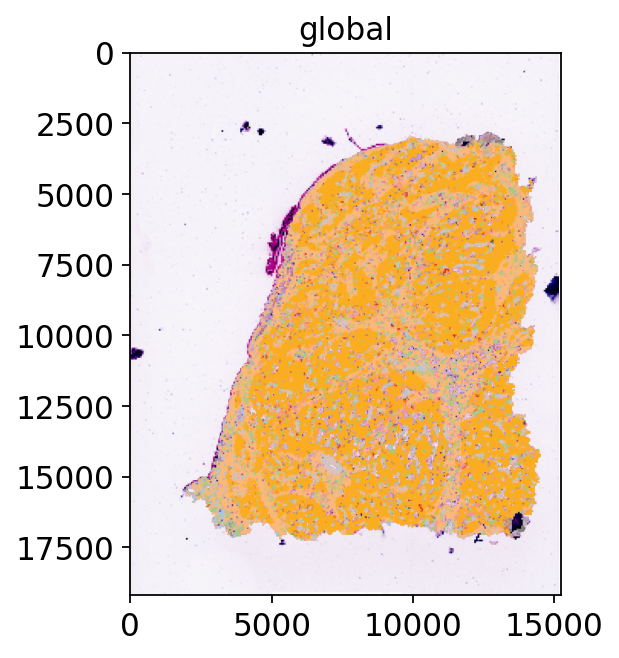

In [19]:
# 1) subset the annotated anndata
section = 'C01'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, f'{section}', change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

# 2) Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [22]:
jpasq.plot_g4x_inset(sdata, section, obs_key=ct_key, palette=ct_color_dict, xmin=5500, ymin=14000, width=2000, height=2000)

/labs/delitto/james/functions/jpasq.py:1214: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


### G03

Created output directory /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/G03
Working directory and scanpy figure output directory changed to /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/G03
AnnData object with n_obs × n_vars = 19763 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'Sample', 'ct'
    uns: 'ct_colors'
    obsm: 'X_spatial'


/labs/delitto/james/functions/jpasq.py:192: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(get_proseg_path(directory, section))
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


SpatialData object, with associated Zarr store: /oak/stanford/groups/longaker/ULMS/G4X/G4X_raw/g4-033-076-FC4-L003_472c4f0ef9f2af777/G03/segmentation/proseg_no_igj/proseg-output.zarr
├── Images
│     └── 'hne': DataArray[cyx] (3, 19200, 15232)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (19763, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (19763, 304)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), transcripts (Points), cell_boundaries (Shapes)
with the following elements not in the Zarr store:
    ▸ hne (Images)


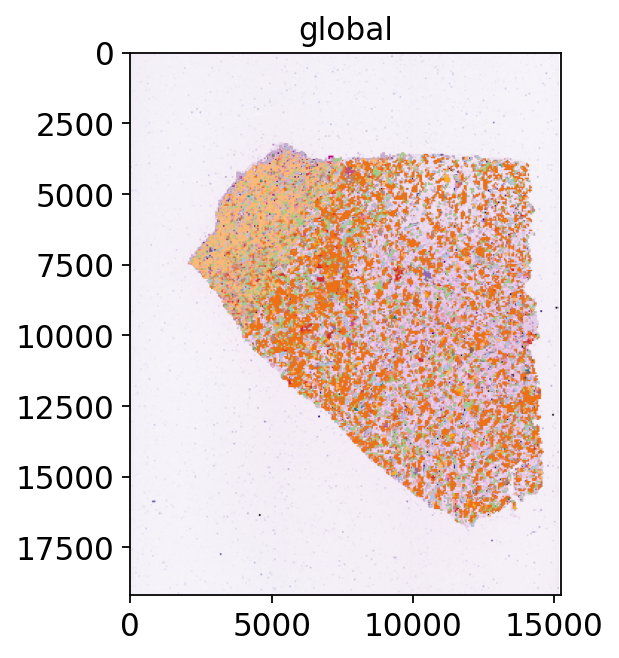

In [23]:
# subset the annotated anndata
section = 'G03'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, f'{section}', change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

# Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [24]:
jpasq.plot_g4x_inset(sdata, section, obs_key=ct_key, palette=ct_color_dict, xmin=4500, ymin=8000, width=2000, height=2000)

/labs/delitto/james/functions/jpasq.py:1214: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


### C03

Created output directory /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/C03
Working directory and scanpy figure output directory changed to /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/C03
AnnData object with n_obs × n_vars = 68819 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'Sample', 'ct'
    uns: 'ct_colors'
    obsm: 'X_spatial'


/labs/delitto/james/functions/jpasq.py:192: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(get_proseg_path(directory, section))
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


SpatialData object, with associated Zarr store: /oak/stanford/groups/longaker/ULMS/G4X/G4X_raw/g4-033-076-FC4-L003_472c4f0ef9f2af777/C03/segmentation/proseg_no_igj/proseg-output.zarr
├── Images
│     └── 'hne': DataArray[cyx] (3, 19200, 15232)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (68819, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (68819, 304)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), transcripts (Points), cell_boundaries (Shapes)
with the following elements not in the Zarr store:
    ▸ hne (Images)


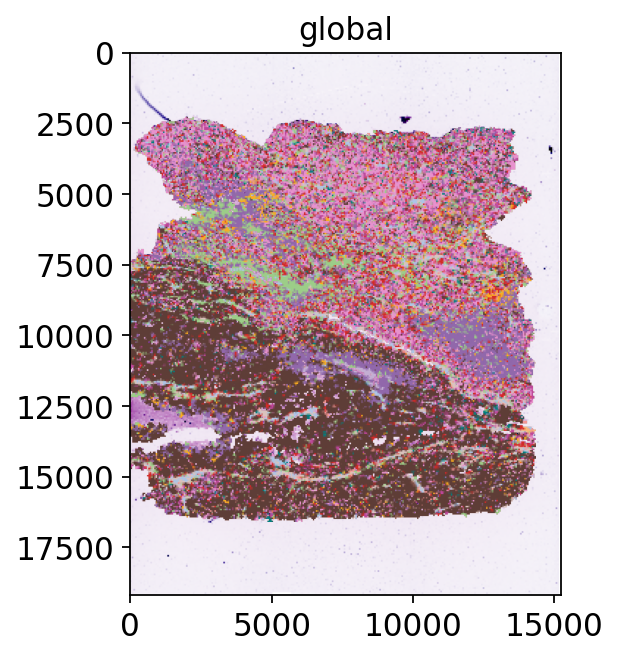

In [25]:
# subset the annotated anndata
section = 'C03'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, f'{section}', change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

# Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [26]:
jpasq.plot_g4x_inset(sdata, section, obs_key=ct_key, palette=ct_color_dict, xmin=7000, ymin=10000, width=2000, height=2000)

/labs/delitto/james/functions/jpasq.py:1214: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


### F03

Created output directory /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/F03
Working directory and scanpy figure output directory changed to /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_figures/F03
AnnData object with n_obs × n_vars = 45860 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'Sample', 'ct'
    uns: 'ct_colors'
    obsm: 'X_spatial'


/labs/delitto/james/functions/jpasq.py:192: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(get_proseg_path(directory, section))
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


SpatialData object, with associated Zarr store: /oak/stanford/groups/longaker/ULMS/G4X/G4X_raw/g4-033-076-FC4-L003_472c4f0ef9f2af777/F03/segmentation/proseg_no_igj/proseg-output.zarr
├── Images
│     └── 'hne': DataArray[cyx] (3, 19200, 15232)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (45860, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (45860, 304)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), transcripts (Points), cell_boundaries (Shapes)
with the following elements not in the Zarr store:
    ▸ hne (Images)


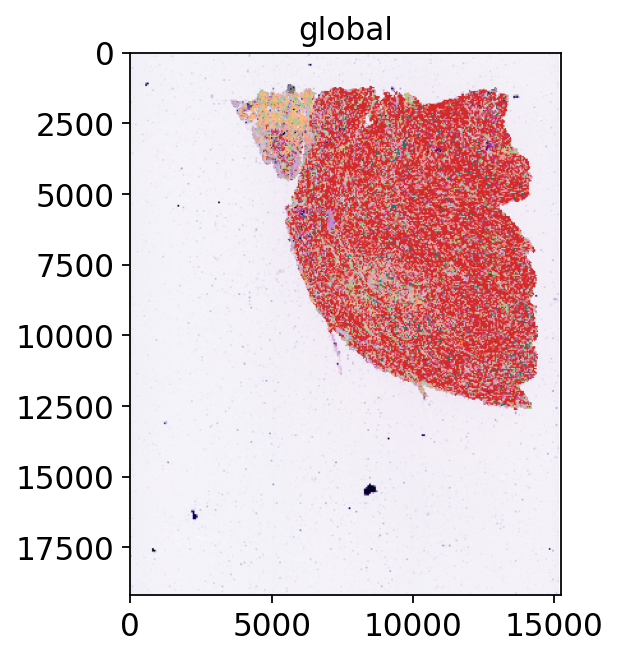

In [27]:
# subset the annotated anndata
section = 'F03'
output_dir = jpasq.create_output_dir(OUTPUT_MASTER_DIR, f'{section}', change_dir=True)
adata = all_cells[all_cells.obs['Section'] == section].copy()
print(adata)
# load spatialdata object
sdata = jpasq.load_g4x_zarr(DATA_DIR, section, proseg_folder_label='proseg_no_igj')
# connect the annotated anndata to the spatialdata object
sdata = jpasq.connect_adata_to_sdata(adata, sdata)
print(sdata)

# Make the colors consistent with the original object.
groups = np.unique(adata.obs[ct_key]).tolist()
ct_color_dict = {key: ct_palette[key] for key in groups if key in ct_palette}
custom_palette = list(ct_color_dict.values())
# check that coordinate system for the H&E image is lined up properly
sdata.pl.render_images('hne').pl.render_shapes(color=ct_key, groups=groups, palette=custom_palette).pl.show(legend_loc=None)

In [28]:
jpasq.plot_g4x_inset(sdata, section, obs_key=ct_key, palette=ct_color_dict, xmin=9000, ymin=8000, width=2000, height=2000)

/labs/delitto/james/functions/jpasq.py:1214: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0., frameon=False)
/home/jpagolia/miniforge3/envs/jpa_squidpy/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
